In [10]:
import os
import numpy as np
from monai.data import DataLoader, Dataset, CacheDataset
from monai.transforms import (
    AddChanneld,
    Compose,
    LoadImaged,
    RandAffined,
    Resized,
    ScaleIntensityRanged,
    EnsureTyped,
)



def getDataLoader(batch_size=1):
    data_dir = "/zhaosheng_data/4dct_2"
    data_inputs = []
    for item in [_file.split("_")[0] for _file in os.listdir(data_dir) if "t9" in _file]:
        if item not in data_inputs:
            data_inputs.append(item)

    data_dicts = [
        {
            "image": os.path.join(data_dir,
                                        f"{idx}_t0.nii"),
            "label": os.path.join(data_dir,
                                        f"{idx}_t5.nii"),
            "pid": f"{idx}"
        }
        for idx in sorted(data_inputs)
    ]

    train_files, val_files = data_dicts[:2], data_dicts[-2:]
    #print(val_files)
    train_transforms = Compose(
        [
            LoadImaged(
                keys=["image","label"]
            ),
            AddChanneld(
                keys=["image","label"]
            ),
            ScaleIntensityRanged(
                keys=["image","label"],
                a_min=-1000, a_max=2000, b_min=0.0, b_max=1.0, clip=True,
            ),
            RandAffined(
                keys=["image","label"],
                mode=('bilinear', 'bilinear'),
                prob=1.0, spatial_size=(128, 128, 64),
                rotate_range=(0, 0, np.pi / 15), scale_range=(0.1, 0.1, 0.1)
            ),
            Resized(
                keys=["image","label"],
                mode=('trilinear', 'trilinear'),
                align_corners=(True, True),
                spatial_size=(128,128,64)
            ),
            EnsureTyped(
                keys=["image","label"]
            ),
        ]
    )
    val_transforms = Compose(
        [
            LoadImaged(
                keys=["image","label"],
            ),
            AddChanneld(
                keys=["image","label"],
            ),
            ScaleIntensityRanged(
                keys=["image","label"],
            a_min=-1000, a_max=2000,b_min=0.0, b_max=1.0,
                clip=True,
            ),
            Resized(
                keys=["image","label"],
                mode=('trilinear', 'trilinear'),
                align_corners=(True, True),
                spatial_size=(128,128,64)
            ),
            EnsureTyped(
                keys=["image","label"],
            ),
        ]
    )
    train_ds = CacheDataset(data=train_files, transform=train_transforms,
                            cache_rate=1.0, num_workers=40)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=40
                              )
    val_ds = CacheDataset(data=val_files, transform=val_transforms,
                        cache_rate=1.0, num_workers=40)
    val_loader = DataLoader(val_ds, batch_size=1, num_workers=40)

    return train_loader,val_loader

In [11]:
import os
import torch
import monai
import numpy as np
import ants
from torch.nn import MSELoss,L1Loss

torch.multiprocessing.set_sharing_strategy('file_system')
os.environ['CUDA_VISIBLE_DEVICES'] = '0,1'
monai.utils.set_determinism(seed=0)

train_loader,val_loader = getDataLoader(batch_size=2)
device = torch.device("cuda:1")

net = monai.networks.nets.RegUNet(spatial_dims=3, num_channel_initial=16, depth=5, in_channels=1,  out_channels=3)#num_channel_initial=3, depth=3,
net = net.to(device)


image_loss = L1Loss()
optimizer = torch.optim.Adam(net.parameters(), 1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=10, factor=0.1, min_lr=0.0000002)

Loading dataset: 100%|██████████| 2/2 [00:04<00:00,  2.07s/it]


In [12]:
%matplotlib inline
from monai.optimizers import LearningRateFinder
lower_lr, upper_lr = 1e-5, 1e-0
lr_finder = LearningRateFinder(net, optimizer, image_loss, device=device)
lr_finder.range_test(train_loader, val_loader, end_lr=upper_lr, num_iter=20)
steepest_lr, _ = lr_finder.get_steepest_gradient()


Computing optimal learning rate:   0%|          | 0/20 [00:00<?, ?it/s]/opt/anaconda3/lib/python3.8/site-packages/torch/nn/modules/loss.py:96: UserWarning:

Using a target size (torch.Size([2, 1, 128, 128, 64])) that is different to the input size (torch.Size([2, 3, 128, 128, 64])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.

/opt/anaconda3/lib/python3.8/site-packages/torch/nn/modules/loss.py:96: UserWarning:

Using a target size (torch.Size([1, 1, 128, 128, 64])) that is different to the input size (torch.Size([1, 3, 128, 128, 64])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.

Computing optimal learning rate:  50%|█████     | 10/20 [04:13<04:13, 25.31s/it]


Stopping early, the loss has diverged
Resetting model and optimizer


NameError: name 'plt' is not defined

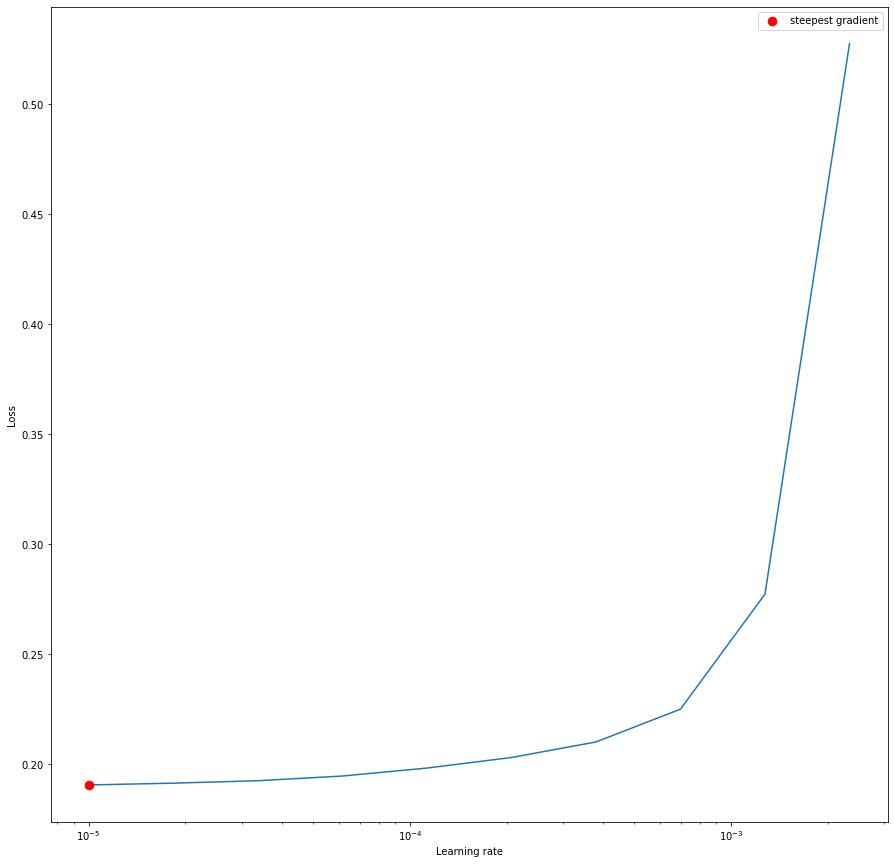

In [13]:
import matplotlib.pyplot as plt
ax = plt.subplots(1, 1, figsize=(15, 15), facecolor="white")[1]
_ = lr_finder.plot(ax=ax)

In [46]:
import ants
import antspynet
import monai
import os
from tqdm import tqdm

def save_largest(raw_img):
    npy = raw_img.numpy()
    npy[npy>0.5]=1
    npy[npy<=0.5]=0
    npy2 = monai.transforms.utils.get_largest_connected_component_mask(npy, connectivity=None)
    post_img = ants.from_numpy(npy2)
    post_img.set_spacing(raw_img.spacing)
    post_img.set_origin(raw_img.origin)
    return post_img

def get_filename(filepath):
    return filepath.split("/")[-1].split(".")[0]
def get_lung_mask(filepath,savepath=None,plot=False):
    img = ants.image_read(filepath)
    output = antspynet.utilities.lung_extraction(img, modality="ct")
    left_lung = output["probability_images"][1]
    right_lung = output["probability_images"][2]
    left_lung = save_largest(left_lung)
    right_lung = save_largest(right_lung)
    
    if savepath != None:
        plotpath=os.path.join(savepath,"plots")
        os.makedirs(plotpath,exist_ok=True)
        left_path = os.path.join(savepath,get_filename(filepath)+"_left_lung.nii")
        right_path = os.path.join(savepath,get_filename(filepath)+"_right_lung.nii")
        if plot:
            left_lung.plot(axis=1,overlay=img,overlay_alpha=0.5,filename=os.path.join(plotpath,get_filename(filepath)+"_left_lung.png"))
            right_lung.plot(axis=1,overlay=img,overlay_alpha=0.5,filename=os.path.join(plotpath,get_filename(filepath)+"_right_lung.png"))
        ants.image_write(left_lung,left_path)
        ants.image_write(right_lung,right_path)
        #print(f"Save to: \n\t{left_path}\n\t{right_path}")
    return left_lung,right_lung

if __name__ == "__main__":
    root = "/zhaosheng_data/4dct_2/"
    niis = [os.path.join(root,_file) for _file in os.listdir(root) if ".nii" in _file]

    for filepath in tqdm(niis):
        try:
            get_lung_mask(filepath,savepath="/zhaosheng_data/4dct_2_lungs/",plot=True)
        except:
            print(f"Pass {filepath}")



  0%|          | 0/2057 [01:30<?, ?it/s]


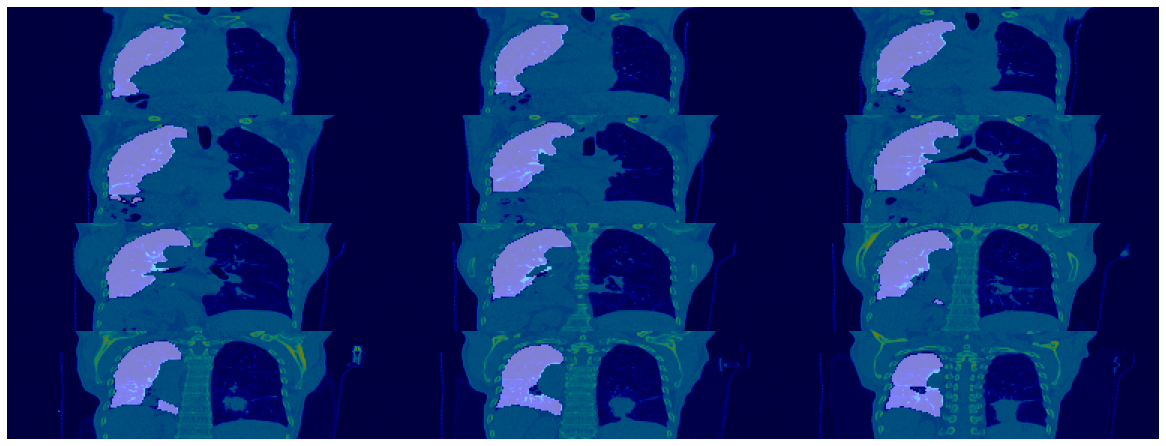

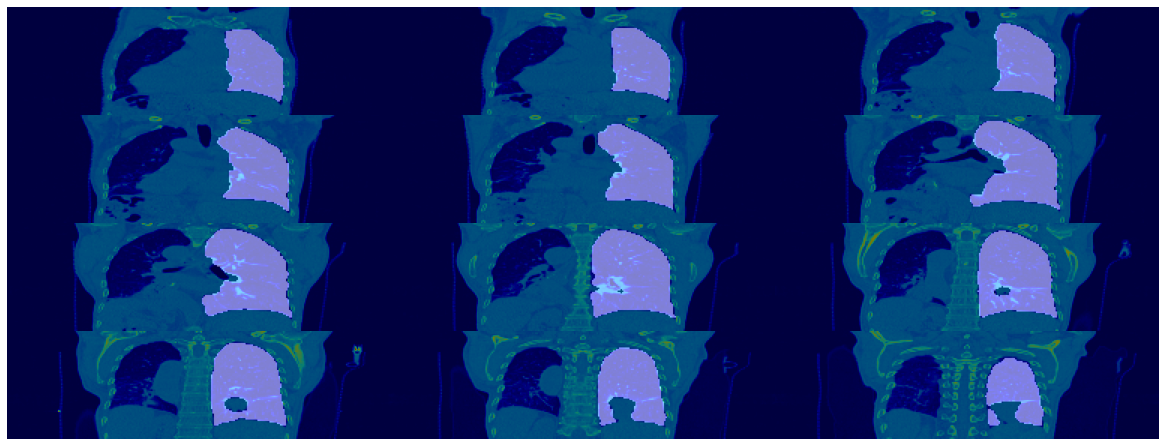

Save to: 
	/zhaosheng_data/4dct_2_lungs/187394_t5_left_lung.nii
	/zhaosheng_data/4dct_2_lungs/187394_t5_right_lung.nii


(ANTsImage (RAI)
 	 Pixel Type : float (float32)
 	 Components : 1
 	 Dimensions : (256, 256, 72)
 	 Spacing    : (1.9531, 1.9531, 4.0)
 	 Origin     : (-249.5117, -433.5117, -976.0)
 	 Direction  : [1. 0. 0. 0. 1. 0. 0. 0. 1.],
 ANTsImage (RAI)
 	 Pixel Type : float (float32)
 	 Components : 1
 	 Dimensions : (256, 256, 72)
 	 Spacing    : (1.9531, 1.9531, 4.0)
 	 Origin     : (-249.5117, -433.5117, -976.0)
 	 Direction  : [1. 0. 0. 0. 1. 0. 0. 0. 1.])

 76%|███████▌  | 1556/2057 [00:00<00:00, 7903.55it/s] 

/zhaosheng_data/4dct_2/340297_t2.nii
/zhaosheng_data/4dct_2/187394_t1.nii
/zhaosheng_data/4dct_2/328272_t8.nii
/zhaosheng_data/4dct_2/345755_t6.nii
/zhaosheng_data/4dct_2/257904_t9.nii
/zhaosheng_data/4dct_2/330477_t3.nii
/zhaosheng_data/4dct_2/329879_t1.nii
/zhaosheng_data/4dct_2/299580_t9.nii
/zhaosheng_data/4dct_2/347997_t2.nii
/zhaosheng_data/4dct_2/336280_t1.nii
/zhaosheng_data/4dct_2/306663_t9.nii
/zhaosheng_data/4dct_2/330477_t6.nii
/zhaosheng_data/4dct_2/324124_t2.nii
/zhaosheng_data/4dct_2/332466_t6.nii
/zhaosheng_data/4dct_2/205426_t0.nii
/zhaosheng_data/4dct_2/314560_t2.nii
/zhaosheng_data/4dct_2/325987_t9.nii
/zhaosheng_data/4dct_2/343279_t3.nii
/zhaosheng_data/4dct_2/346699_t3.nii
/zhaosheng_data/4dct_2/278242_t2.nii
/zhaosheng_data/4dct_2/337019_t0.nii
/zhaosheng_data/4dct_2/332466_t5.nii
/zhaosheng_data/4dct_2/321911_t5.nii
/zhaosheng_data/4dct_2/354270_t2.nii
/zhaosheng_data/4dct_2/336400_t8.nii
/zhaosheng_data/4dct_2/321911_t4.nii
/zhaosheng_data/4dct_2/331048_t5.nii
/

100%|██████████| 2057/2057 [00:00<00:00, 6221.16it/s]


/zhaosheng_data/4dct_2/328157_t0.nii
/zhaosheng_data/4dct_2/311586_t4.nii
/zhaosheng_data/4dct_2/328176_t0.nii
/zhaosheng_data/4dct_2/290029_t0.nii
/zhaosheng_data/4dct_2/335929_t4.nii
/zhaosheng_data/4dct_2/327387_t0.nii
/zhaosheng_data/4dct_2/328271_t9.nii
/zhaosheng_data/4dct_2/195578_t5.nii
/zhaosheng_data/4dct_2/278481_t1.nii
/zhaosheng_data/4dct_2/307733_t2.nii
/zhaosheng_data/4dct_2/319534_t5.nii
/zhaosheng_data/4dct_2/294049_t1.nii
/zhaosheng_data/4dct_2/341238_t1.nii
/zhaosheng_data/4dct_2/327204_t6.nii
/zhaosheng_data/4dct_2/344311_t7.nii
/zhaosheng_data/4dct_2/329156_t2.nii
/zhaosheng_data/4dct_2/338183_t3.nii
/zhaosheng_data/4dct_2/345042_t9.nii
/zhaosheng_data/4dct_2/338541_t3.nii
/zhaosheng_data/4dct_2/307733_t6.nii
/zhaosheng_data/4dct_2/271636_t4.nii
/zhaosheng_data/4dct_2/333374_t6.nii
/zhaosheng_data/4dct_2/322400_t1.nii
/zhaosheng_data/4dct_2/329807_t1.nii
/zhaosheng_data/4dct_2/340659_t2.nii
/zhaosheng_data/4dct_2/300510_t5.nii
/zhaosheng_data/4dct_2/271636_t5.nii


2057

In [66]:
from time import *
import ants
import shutil
import os
def get_transform(moving_path, fixed_path,type_of_transform="SyNRA",plots_path="/zhaosheng_data/4dct_transform_all_png",transform_path="/zhaosheng_data/4dct_transform_all"):
    os.environ["ITK_GLOBAL_DEFAULT_NUMBER_OF_THREADS"] = "80"
    os.environ["ANTS_RANDOM_SEED"] = "3"
    os.makedirs(plots_path,exist_ok=True)
    os.makedirs(transform_path,exist_ok=True)
    moving = ants.image_read(moving_path)
    fixed = ants.image_read(fixed_path)
    begin_time = time()
    filename = fixed_path.split("/")[-1].split(".")[-2]
    suffix=moving_path.split("/")[-1].split(".")[-2].split("_")[-1]+fixed_path.split("/")[-1].split(".")[-2].split("_")[-1]
    reg = ants.registration(
        fixed=fixed, moving=moving, type_of_transform=type_of_transform, reg_iterations=[100, 100, 40])

    moved = reg["warpedmovout"]
    moved2 = moved +1000
    moved2.plot(title='moved', axis=1, cbar=True,
            filename=os.path.join(plots_path, filename+"_moved.png"))

    ants.plot(moved2, overlay=fixed, overlay_cmap='hot', overlay_alpha=0.5,
            axis=1, cbar=True, filename=os.path.join(plots_path, filename+"_overlay_1.png"))
    ants.plot(moved2, overlay=fixed, overlay_cmap='hot', overlay_alpha=0.5,
            axis=0, cbar=True, filename=os.path.join(plots_path, filename+"_overlay_0.png"))
    # SAVE transform

    end_time = time()
    run_time = end_time-begin_time

    for output_file in reg["fwdtransforms"]:
        if "nii" in output_file:
            shutil.move(output_file, f"{transform_path}/{filename}_{suffix}.nii.gz")
            return run_time,f"{transform_path}/{filename}.nii.gz"

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


In [69]:
for i in range(5):
    used_time,output_file = get_transform(f"/zhaosheng_data/4dct_2/120829_t{i}.nii",f"/zhaosheng_data/4dct_2/120829_t{i+1}.nii")

In [70]:
used_time,output_file = get_transform(f"/zhaosheng_data/4dct_2/120829_t0.nii",f"/zhaosheng_data/4dct_2/120829_t5.nii")

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


In [100]:
import ants
tm01 = ants.image_read("/zhaosheng_data/4dct_transform_all/120829_t1_t0t1.nii.gz")
tm12 = ants.image_read("/zhaosheng_data/4dct_transform_all/120829_t2_t1t2.nii.gz")
tm23 = ants.image_read("/zhaosheng_data/4dct_transform_all/120829_t3_t2t3.nii.gz")
tm34 = ants.image_read("/zhaosheng_data/4dct_transform_all/120829_t4_t3t4.nii.gz")
tm45 = ants.image_read("/zhaosheng_data/4dct_transform_all/120829_t5_t4t5.nii.gz")
tm05 = ants.image_read("/zhaosheng_data/4dct_transform_all/120829_t5_t0t5.nii.gz")
img = ants.image_read("/zhaosheng_data/4dct_2/120829_t0.nii")
# monai

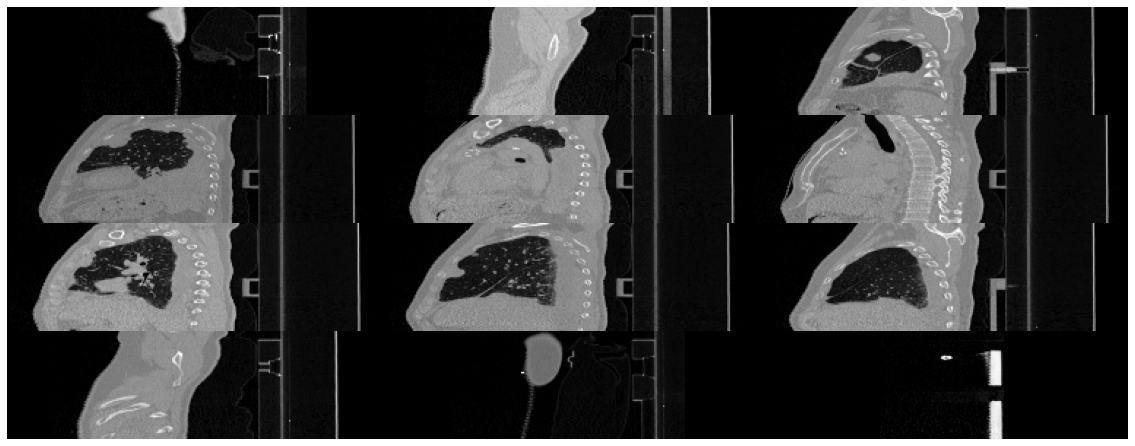

In [98]:

img.plot()

In [112]:
t1_fake=ants.apply_transforms( fixed=ants.image_read("/zhaosheng_data/4dct_2/120829_t1.nii"),moving=img,transformlist="/zhaosheng_data/4dct_transform_all/120829_t1_t0t1.nii.gz" )
t2_fake=ants.apply_transforms( fixed=ants.image_read("/zhaosheng_data/4dct_2/120829_t2.nii"),moving=t1_fake,transformlist="/zhaosheng_data/4dct_transform_all/120829_t2_t1t2.nii.gz" )
t3_fake=ants.apply_transforms( fixed=ants.image_read("/zhaosheng_data/4dct_2/120829_t3.nii"),moving=t2_fake,transformlist="/zhaosheng_data/4dct_transform_all/120829_t3_t2t3.nii.gz" )
t4_fake=ants.apply_transforms( fixed=ants.image_read("/zhaosheng_data/4dct_2/120829_t4.nii"),moving=t3_fake,transformlist="/zhaosheng_data/4dct_transform_all/120829_t4_t3t4.nii.gz" )
t5_fake=ants.apply_transforms( fixed=ants.image_read("/zhaosheng_data/4dct_2/120829_t5.nii"),moving=t4_fake,transformlist="/zhaosheng_data/4dct_transform_all/120829_t5_t4t5.nii.gz" )
t5_real = ants.image_read("/zhaosheng_data/4dct_2/120829_t5.nii")
t5_fake_2 =ants.apply_transforms( fixed=ants.image_read("/zhaosheng_data/4dct_2/120829_t5.nii"),moving=img,transformlist="/zhaosheng_data/4dct_transform_all/120829_t5_t0t5.nii.gz" )

t5_fake_3 =ants.apply_transforms( fixed=ants.image_read("/zhaosheng_data/4dct_2/120829_t5.nii"),moving=img,transformlist=
                                 ["/zhaosheng_data/4dct_transform_all/120829_t1_t0t1.nii.gz",
                                  "/zhaosheng_data/4dct_transform_all/120829_t2_t1t2.nii.gz",
                                  "/zhaosheng_data/4dct_transform_all/120829_t3_t2t3.nii.gz",
                                  "/zhaosheng_data/4dct_transform_all/120829_t4_t3t4.nii.gz",
                                  "/zhaosheng_data/4dct_transform_all/120829_t5_t4t5.nii.gz"] )


`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


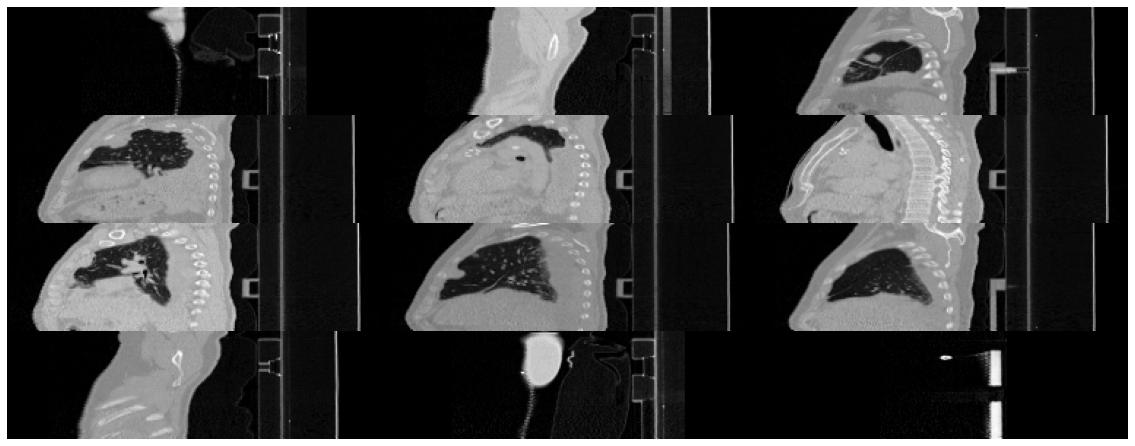

In [113]:
t5_fake_3+=1000
t5_fake_3.plot()

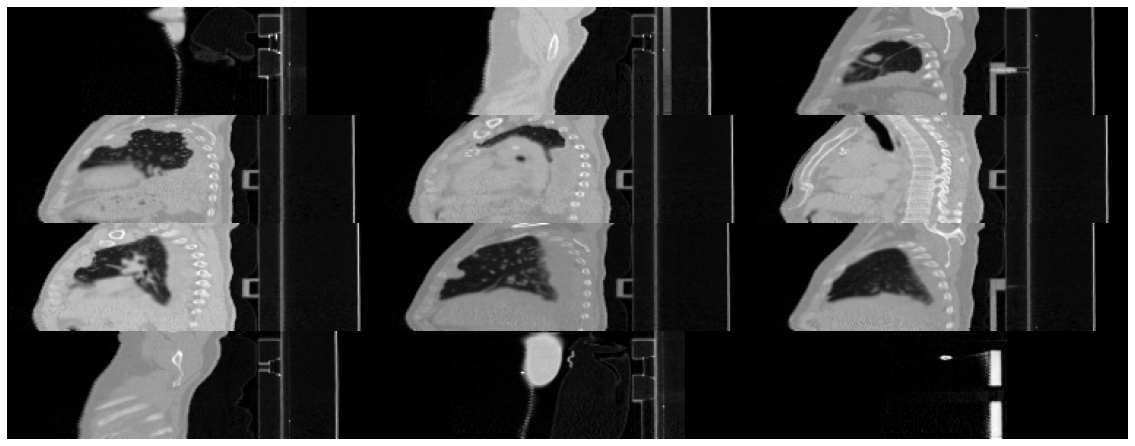

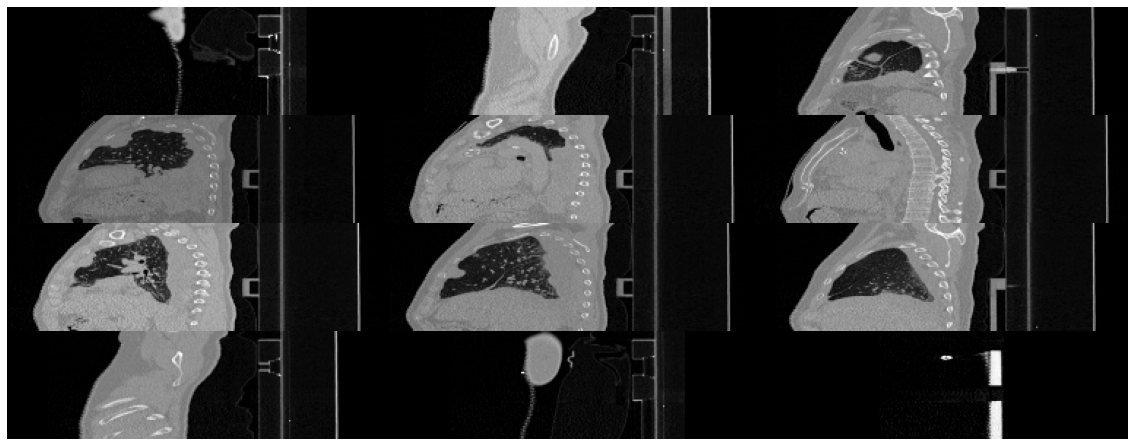

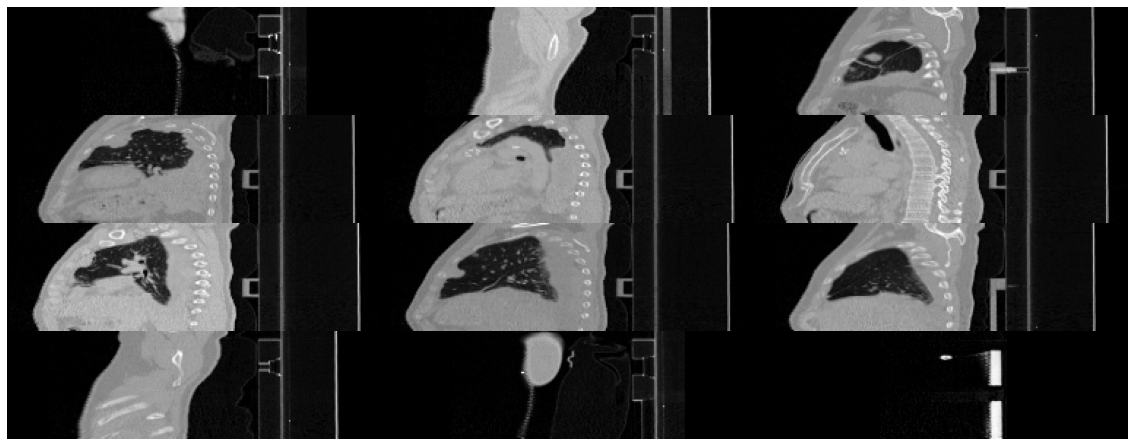

In [111]:
t5_fake+=1000
t5_real+=1000
t5_fake_2+=1000
t5_fake.plot()
t5_real.plot()
t5_fake_2.plot()

In [86]:
from monai.networks.blocks import Warp
import numpy as np
warp = Warp()

monai.networks.blocks.Warp: Using PyTorch native grid_sample.


In [87]:
img_npy = ants.image_read("/zhaosheng_data/4dct_2/120829_t0.nii").numpy().transpose(2,0,1)
img_npy = np.expand_dims(img_npy,axis=0)
img_npy = np.expand_dims(img_npy,axis=0)
img_npy.shape

(1, 1, 74, 256, 256)

In [90]:
ddf_npy = ants.image_read(tm01).numpy().transpose(3,2,0,1)
ddf_npy = np.expand_dims(ddf_npy,axis=0)
ddf_npy.shape

(1, 3, 74, 256, 256)

In [91]:
a = warp(img_npy,ddf_npy)

TypeError: to() received an invalid combination of arguments - got (numpy.ndarray), but expected one of:
 * (torch.device device, torch.dtype dtype, bool non_blocking, bool copy, *, torch.memory_format memory_format)
 * (torch.dtype dtype, bool non_blocking, bool copy, *, torch.memory_format memory_format)
 * (Tensor tensor, bool non_blocking, bool copy, *, torch.memory_format memory_format)


In [1]:

files = sorted([os.path.join("/zhaosheng_data/4dct_2",_file) for _file in os.listdir("/zhaosheng_data/4dct_2") if "_t5" in _file])
for file in files:
    filename = file.split("/")[-1].split("_")[0]
    try:
        get_transform(f"/zhaosheng_data/4dct_2/{filename}_t5.nii",f"/zhaosheng_data/4dct_2/{filename}_t0.nii")
    except:
        print(f"Pass {filename}")

NameError: name 'os' is not defined

In [ ]:
import numpy as np
import ants

In [ ]:
ants.

In [ ]:
raw_img = ants.ima
transform = ants.registration(fixed=fixed , moving=moving ,
                             type_of_transform = 'SyN' )
ants.appley_transforms(fixed,moving,transformlist, interpolator='linear')